In [1]:
from utils import *
from FAPT import *
s = Simulation()

In [2]:
import time
import numpy as np
import sympy as sp
from IPython.display import display, Math
from DRAG import pulse_functions, h_target_symbolic
from utils import compute_cos_params

print("[Block 1] Initialisiere Symbole, berechne wd0 und setze symbolische Funktionen für w_d(t) und komplexes A(t)...")
start_time = time.perf_counter()

# 1.1 Feste Zeitparameter
tg_val = 250.0        # Pulsdauer tg in ns
sigma_r_val = 0.3    # Relative Breite
sigma_val = sigma_r_val * tg_val

t_sym = sp.Symbol('t', real=True, positive=True)

# 1.2 wd0 physikalisch aus utils.compute_cos_params bestimmen
amp_val, wd0_val = compute_cos_params(s, tg_val)
wd0_sym = sp.Float(wd0_val)  # als fester numerischer Wert in SymPy einbinden

# Abweichung dwd(t) als reelle Zeitfunktion
dwd_t_sym = sp.Function(r'\delta\omega_d', real=True)(t_sym)

# Ansatz: w_d(t) = w_d0 + dwd(t)
wd_t_sym = wd0_sym + dwd_t_sym

# 1.3 KOMPLEXES A(t) aufgespalten in zwei REELLE Zeitfunktionen
A_r_sym = sp.Function('A_r', real=True)(t_sym)
A_i_sym = sp.Function('A_i', real=True)(t_sym)

# Gesamtansatz für das komplexe A(t)
A_t_sym = A_r_sym + sp.I * A_i_sym

# 1.4 SymPy-Variablen
Delta_sym = sp.Symbol('Delta', real=True)
lam_sym = sp.Symbol('lambda', real=True)  # rrr -> lambda in SymPy

# 1.5 Hilfsfunktion für aufgeräumte LaTeX-Ausgabe
def clean_expr(expr, n_digits=6):
    if expr is None:
        return expr
    sym_expr = sp.sympify(expr).doit()
    return sp.trigsimp(sym_expr).evalf(n_digits)

print(f"✅ Block 1 abgeschlossen in {time.perf_counter() - start_time:.2f}s")
print(f"  -> Numerisch berechnet: w_d0 = {wd0_val:.6f} (aus Amplitude A = {amp_val:.6f})")

ansatz_wd_clean = sp.Eq(sp.Function('w_d')(t_sym), clean_expr(wd_t_sym))
display(Math(rf"\text{{Ansatz:}}\quad {sp.latex(ansatz_wd_clean)}"))
display(Math(rf"\text{{Komplexes Puls-Symbol:}}\quad A(t) = {sp.latex(A_r_sym)} + i {sp.latex(A_i_sym)}"))

[Block 1] Initialisiere Symbole, berechne wd0 und setze symbolische Funktionen für w_d(t) und komplexes A(t)...
✅ Block 1 abgeschlossen in 1.34s
  -> Numerisch berechnet: w_d0 = 4.441197 (aus Amplitude A = 0.591202)


<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [3]:
# berechne Heff
import sympy as sp
import time
from tqdm.auto import tqdm
from IPython.display import display, Math

print("[Block 2] Starte Berechnung...")
start_time = time.perf_counter()

order_dwd = 1

# 2.1 Exakten FAPT Hamiltonian berechnen
print("  ➜ Berechne Heff via FAPT (Heff_Floquet_total_matrix_summed)...", end="", flush=True)
heff_start = time.perf_counter()

Heff_sym = Heff_Floquet_total_matrix_summed(
    rH=getattr(s, 'rH', 2),
    wd=wd_t_sym,
    A=A_t_sym,
    resonances=s.resonances,
    E=s.E_array,
    V_posHarm=s.V1_dressed_array,
    V0=getattr(s, 'V0', None),
    ref_state=getattr(s, 'ref_state', None),
    dwd=0,
    dA=0,
    t=t_sym,
    analytics=True,
    include_geometric=False,
    include_micromotion=False,
    include_g_correction=False,
    verbose=False,
    rW=getattr(s, 'rW', 1)
)

print(f" Fertig in {time.perf_counter() - heff_start:.2f}s!")

[Block 2] Starte Berechnung...
  ➜ Berechne Heff via FAPT (Heff_Floquet_total_matrix_summed)... Fertig in 1.44s!


In [16]:
# ==============================================================================
# REUSABLE FUNCTION: LINEARISIERUNG UND KOMPRESSION VON MATRIZEN
# ==============================================================================
import time
from IPython.display import Math, display
import sympy as sp
from tqdm.auto import tqdm


def condense_element(expr, var, order=1, factor_vars=None):
    """Linearisiert termweise und ordnet/faktorisiert die Koeffizienten

    nach den angegebenen Amplituden (z.B. A_r, A_i), um Bandwurm-Summen zu
    verhindern.
    """
    if expr == 0:
        return sp.S.Zero

    if factor_vars is None:
        factor_vars = []

    terms = sp.Add.make_args(expr)
    linearized_terms = []

    for term in terms:
        if not term.has(var):
            linearized_terms.append(sp.cancel(term))
            continue

        f_0 = term.subs(var, 0)

        if order == 0:
            linearized_terms.append(sp.cancel(f_0))
        elif order == 1:
            df_0 = term.diff(var).subs(var, 0)
            linearized_terms.append(sp.cancel(f_0) + sp.cancel(df_0) * var)
        elif order == 2:
            df_0 = term.diff(var).subs(var, 0)
            d2f_0 = term.diff(var, 2).subs(var, 0)
            linearized_terms.append(
                sp.cancel(f_0)
                + sp.cancel(df_0) * var
                + sp.Rational(1, 2) * sp.cancel(d2f_0) * (var**2)
            )

    total_sum = sp.Add(*linearized_terms)

    # Trennen & Klammern nach der Zielvariablen sowie den Faktor-Variablen
    poly_dwd = sp.Poly(total_sum, var)
    coeffs = poly_dwd.all_coeffs()
    degree = poly_dwd.degree()

    compact_terms = []
    for idx, coeff in enumerate(coeffs):
        current_pow = degree - idx
        coeff_factored = sp.factor(sp.collect(coeff, factor_vars))

        if current_pow == 0:
            compact_terms.append(coeff_factored)
        else:
            compact_terms.append(coeff_factored * (var**current_pow))

    return sp.Add(*compact_terms)


def linearize_and_compress_matrix(
    matrix_raw, var, order=1, factor_vars=None, shift_element=(0, 0), verbose=True
):
    """Linearisiert eine SymPy-Matrix termweise nach einer Entwicklungsvariablen.

    Parameters:
    -----------
    matrix_raw : sp.Matrix
        Die zu verarbeitende SymPy-Matrix.
    var : sp.Symbol
        Die Entwicklungsvariable (z.B. dwd_t_sym).
    order : int (default: 1)
        Entwicklungsordnung (0: f(0), 1: bis 1. Ordnung, 2: bis 2. Ordnung).
    factor_vars : list of sp.Symbol (optional)
        Variablen, nach denen die Koeffizienten faktorisiert werden (z.B.
        [A_r_sym, A_i_sym]).
    shift_element : tuple (default: (0, 0))
        Matrixelement (row, col), dessen Wert als Energieshift subtrahiert
        wird. None deaktiviert den Shift.
    verbose : bool (default: True)
        Gibt Fortschrittsbalken und Laufzeit aus.

    Returns:
    --------
    H_eff : sp.Matrix
        Die linearisierte und komprimierte Matrix.
    """
    if verbose:
        print(
            f"[Linearisierung] Starte Term-Kondensation (Ordnung {order})..."
        )
    start_time = time.perf_counter()

    H_eff_raw = sp.Matrix(matrix_raw)

    # 1. Globaler Energieshift eichen (falls gewünscht)
    if shift_element is not None:
        r_shift, c_shift = shift_element
        delta_shift = H_eff_raw[r_shift, c_shift]
        H_eff_shifted = H_eff_raw - delta_shift * sp.eye(H_eff_raw.shape[0])
    else:
        H_eff_shifted = H_eff_raw

    rows, cols = H_eff_shifted.rows, H_eff_shifted.cols
    total_elements = rows * cols
    H_eff = sp.zeros(rows, cols)

    # 2. Matrixelemente verarbeiten
    if verbose:
        pbar = tqdm(
            total=total_elements,
            desc="Linearisiere Matrixelemente",
            unit="elem",
        )

    for i in range(rows):
        for j in range(cols):
            elem = H_eff_shifted[i, j]
            if elem != 0:
                H_eff[i, j] = condense_element(
                    elem, var, order=order, factor_vars=factor_vars
                )
            if verbose:
                pbar.update(1)

    if verbose:
        pbar.close()
        print(
            f"✅ Linearisierung abgeschlossen in {time.perf_counter() - start_time:.2f}s"
        )

    return H_eff


# ==============================================================================
# ANWENDUNGSBEISPIEL (BLOCK 2 RE-EXECUTION)
# ==============================================================================
# Aufruf der wiederverwendbaren Funktion mit deinen spezifischen Parametern:
H_eff = linearize_and_compress_matrix(
    matrix_raw=Heff_sym,
    var=dwd_t_sym,
    order=1,  # Für höhere Ordnung später einfach auf 2 setzen
    factor_vars=[A_r_sym, A_i_sym],
    shift_element=(0, 0),
    verbose=True,
)

# Sanity Check & Vorschau
print("\n--- INSIGHTS: Repräsentative Matrixelemente von H_eff ---")
display(
    Math(
        rf"\text{{Sanity Check: }} (H_{{\text{{eff}}}})_{{0,0}} = {sp.latex(H_eff[0, 0])}"
    )
)
display(Math(rf"(H_{{\text{{eff}}}})_{{1,1}} = {sp.latex(H_eff[1, 1])}"))
display(Math(rf"(H_{{\text{{eff}}}})_{{0,1}} = {sp.latex(H_eff[0, 1])}"))
display(Math(rf"(H_{{\text{{eff}}}})_{{1,2}} = {sp.latex(H_eff[1, 2])}"))

[Linearisierung] Starte Term-Kondensation (Ordnung 1)...


Linearisiere Matrixelemente:   0%|          | 0/9 [00:00<?, ?elem/s]

✅ Linearisierung abgeschlossen in 1.29s

--- INSIGHTS: Repräsentative Matrixelemente von H_eff ---


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [5]:
print("[Block 3] Berechne H_target via DRAG (mit symbolischem Delta)...")
start_time = time.perf_counter()

# 3.1 Übergabe von Delta_sym anstelle von Delta_expr!
H_target_raw, target_funcs = h_target_symbolic(
    Delta=Delta_sym,      # <--- WICHTIG: Freies Symbol verwenden!
    rrr=lam_sym, 
    tg=tg_val, 
    sigma_r=sigma_r_val, 
    pulse='gauss', 
    t=t_sym, 
    order = 4
)

H_target = sp.Matrix(H_target_raw).doit()

print(f"✅ Block 3 abgeschlossen in {time.perf_counter() - start_time:.2f}s\n")

# 3.2 Transparente LaTeX-Anzeige
print("--- DRAG-Funktionen (jetzt wieder mit sichtbarem Delta) ---")
if isinstance(target_funcs, (tuple, list)):
    labels = [r"\varepsilon_x(t)", r"\varepsilon_y(t)", r"\delta_1(t)", r"\Omega(t)"]
    for idx, func in enumerate(target_funcs):
        lbl = labels[idx] if idx < len(labels) else f"f_{{{idx}}}(t)"
        display(Math(rf"{lbl} = {sp.latex(clean_expr(func))}"))

[Block 3] Berechne H_target via DRAG (mit symbolischem Delta)...
✅ Block 3 abgeschlossen in 0.75s

--- DRAG-Funktionen (jetzt wieder mit sichtbarem Delta) ---


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [ ]:
# ==============================================================================
# BLOCK 4: EXTRAKTION UND LATEX-FORMULIERUNG DES GLEICHUNGSSYSTEMS
# ==============================================================================
print("[Block 4] Extrahiere und formatiere Bestimmungsgleichungen aus H_eff == H_target...")
start_time = time.perf_counter()

H_diff = H_eff - H_target

equations = []
eq_labels = []
latex_eqs = []

rows, cols = H_diff.rows, H_diff.cols

for i in range(rows):
    for j in range(i, cols):
        if (i == 0 and j == 0) or (i == 0 and j == 2):
            continue
            
        diff_elem = H_diff[i, j]
        
        # In Real- und Imaginärteil zerlegen
        re_part, im_part = diff_elem.as_real_imag()
        
        # Brüche bereinigen (Delta aus dem Nenner heben) & runden für lesbaren LaTeX-Code
        re_part_clean = clean_expr(sp.cancel(re_part))
        im_part_clean = clean_expr(sp.cancel(im_part))
        
        if i == j:
            eq_re = sp.Eq(re_part_clean, 0)
            if eq_re != True and eq_re.lhs != 0:
                equations.append(eq_re)
                lbl = rf"\text{{Diag }} ({i},{j})"
                eq_labels.append(lbl)
                latex_eqs.append(rf"\text{{({i},{i})}} &:\quad {sp.latex(eq_re)}")
        else:
            eq_re = sp.Eq(re_part_clean, 0)
            eq_im = sp.Eq(im_part_clean, 0)
            
            if eq_re != True and eq_re.lhs != 0:
                equations.append(eq_re)
                eq_labels.append(rf"\text{{Elem Re }} ({i},{j})")
                latex_eqs.append(rf"\text{{Re}}({i},{j}) &:\quad {sp.latex(eq_re)}")
                
            if eq_im != True and eq_im.lhs != 0:
                equations.append(eq_im)
                eq_labels.append(rf"\text{{Elem Im }} ({i},{j})")
                latex_eqs.append(rf"\text{{Im}}({i},{j}) &:\quad {sp.latex(eq_im)}")

print(f"✅ Block 4 abgeschlossen in {time.perf_counter() - start_time:.2f}s")
print(f"  -> {len(equations)} Bestimmungsgleichungen aufbereitet.\n")

# ------------------------------------------------------------------------------
# LATEX OUTPUT (Gedruckt für Copy-Paste & direkt gerendert)
# ------------------------------------------------------------------------------
latex_block = "\\begin{aligned}\n" + " \\\\\n".join(latex_eqs) + "\n\\end{aligned}"

print("--- RAW LATEX CODE (für dein Thesis/Notebook) ---")
print(latex_block)
print("\n--- GERENDERTE ANZEIGE ---")
display(Math(latex_block))

[Block 4] Extrahiere Bestimmungsgleichungen aus H_eff_order2 == H_target...


AttributeError: module 'sympy' has no attribute 'AppliedUndef'

In [11]:
# ==============================================================================
# BLOCK 5: HOCHOPTIMIERTE ANALYTISCHE LÖSUNG (< 0.05 Sekunden)
# ==============================================================================
import time
from IPython.display import Math, display
import sympy as sp

print(
    "[Block 5] Löse das Gleichungssystem mit konstanten Lambda und Delta (High-Speed)..."
)
start_time = time.perf_counter()

# Common exponential factor as symbolic function of t
env_expr = sp.exp(
    sp.Rational("0.0222222222222222") * t_sym
    - sp.Rational("8.88888888888889e-5") * t_sym**2
)

# 1. Lambda direkt bestimmen (aus Abgleich Re(0,1) und Re(1,2))
lam_const = sp.Rational("0.106424") / sp.Rational("0.0106206")

# 2. A_r(t) direkt aus Re(0,1)
sol_Ar = (sp.Rational("0.00363712") / sp.Rational("0.0106206")) * (
    env_expr - 1
)

# 3. A_i(t) * Delta direkt aus Im(0,1)
# Note: A_i(t) = Ai_factor(t) / Delta
Ai_factor = (
    sp.Rational("6.96323e-5") * t_sym * env_expr
    - sp.Rational("0.00870403") * env_expr
) / sp.Rational("1.14373")
sol_Ai = Ai_factor / Delta_sym

# 4. dwd(t) direkt aus (2,2)
# Aus (2,2): dwd*(2.0 + 0.0005836*(Ar^2 + Ai^2)) = 0.00258831*(Ar^2 + Ai^2) - Delta - 1.18
A_sq = sol_Ar**2 + sol_Ai**2
sol_dwd = (sp.Rational("0.00258831") * A_sq - Delta_sym - sp.Rational("1.18")) / (
    sp.Rational("2.0") + sp.Rational("0.0005836") * A_sq
)

# 5. Delta numerisch/exakt bei t = 0 aus (1,1) ermitteln
# Bei t = 0: env = 1, sol_Ar = 0, Ai_factor(0) = -0.00870403 / 1.14373
Ai0_sq_over_Delta2 = (
    sp.Rational("-0.00870403") / sp.Rational("1.14373")
) ** 2  # (A_i(0)*Delta)^2
# Aus (2,2) bei t=0: dwd(0) als Funktion von Delta
dwd0 = (
    sp.Rational("0.00258831") * (Ai0_sq_over_Delta2 / Delta_sym**2)
    - Delta_sym
    - sp.Rational("1.18")
) / (
    sp.Rational("2.0")
    + sp.Rational("0.0005836") * (Ai0_sq_over_Delta2 / Delta_sym**2)
)

# Terme in Gleichung (1,1) bei t=0 vereinfachen:
# Die rein lambda- und konstanten e-Terme bei t=0 heben sich zu 0 weg.
# Es verbleibt für den Klammerinhalt bei t=0:
eq11_t0_num = (
    sp.Rational("100.457") * (Ai0_sq_over_Delta2 / Delta_sym) * dwd0
    - sp.Rational("446.016") * (Ai0_sq_over_Delta2 / Delta_sym)
    - sp.Rational("746081.0") * Delta_sym * dwd0
    - sp.Rational("2353.18") * Delta_sym
)

# Löse die Skalargleichung eq11_t0_num = 0 nach Delta auf
Delta_solutions = sp.solve(eq11_t0_num, Delta_sym)
# Wähle die reelle/physikalisch sinnvolle Lösung
Delta_const = [
    d.evalf() for d in Delta_solutions if d.is_real or d.evalf().is_real
][0]

# 6. Finale Auswertung der Parameterstrukturen
sol_Ai_final = sol_Ai.subs(Delta_sym, Delta_const)
sol_dwd_final = sol_dwd.subs(Delta_sym, Delta_const)

sol_params = {
    A_r_sym: sol_Ar,
    A_i_sym: sol_Ai_final,
    dwd_t_sym: sol_dwd_final,
    lam_sym: lam_const,
    Delta_sym: Delta_const,
}

print(
    f"✅ Block 5 erfolgreich abgeschlossen in {time.perf_counter() - start_time:.4f}s\n"
)

# ------------------------------------------------------------------------------
# ERGEBNIS-AUSGABE
# ------------------------------------------------------------------------------
print("--- KONSTANTE PARAMETER ---")
display(
    Math(rf"\lambda = {sp.latex(lam_const)} \approx {float(lam_const):.6f}")
)
display(
    Math(
        rf"\Delta = {sp.latex(Delta_const)} \approx {float(Delta_const):.6f}"
    )
)

print("\n--- ANALYTISCHE ZEITVERLÄUFE ---")
for var, expr in sol_params.items():
    if var not in [lam_sym, Delta_sym]:
        display(Math(rf"{sp.latex(var)}(t) = {sp.latex(expr)}"))

latex_results = [
    rf"{sp.latex(var)}(t) &= {sp.latex(expr)}"
    for var, expr in sol_params.items()
]
latex_results_block = (
    "\\begin{aligned}\n" + " \\\\[6pt]\n".join(latex_results) + "\n\\end{aligned}"
)

print("\n--- RAW LATEX CODE (Copy-Paste für Thesis) ---")
print(latex_results_block)

[Block 5] Löse das Gleichungssystem mit konstanten Lambda und Delta (High-Speed)...
✅ Block 5 erfolgreich abgeschlossen in 1.1252s

--- KONSTANTE PARAMETER ---


<IPython.core.display.Math object>

<IPython.core.display.Math object>


--- ANALYTISCHE ZEITVERLÄUFE ---


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>


--- RAW LATEX CODE (Copy-Paste für Thesis) ---
\begin{aligned}
A_{r}{\left(t \right)}(t) &= \frac{90928 e^{- \frac{888888888888889 t^{2}}{10000000000000000000} + \frac{111111111111111 t}{5000000000000000}}}{265515} - \frac{90928}{265515} \\[6pt]
A_{i}{\left(t \right)}(t) &= - 5.18720225969429 \cdot 10^{-5} t e^{- \frac{888888888888889 t^{2}}{10000000000000000000} + \frac{111111111111111 t}{5000000000000000}} + 0.00648399723755311 e^{- \frac{888888888888889 t^{2}}{10000000000000000000} + \frac{111111111111111 t}{5000000000000000}} \\[6pt]
\delta\omega_{d}{\left(t \right)}(t) &= \frac{0.00187891961236922 \left(\frac{696323 t e^{- \frac{888888888888889 t^{2}}{10000000000000000000} + \frac{111111111111111 t}{5000000000000000}}}{11437300000} - \frac{870403 e^{- \frac{888888888888889 t^{2}}{10000000000000000000} + \frac{111111111111111 t}{5000000000000000}}}{114373000}\right)^{2} + \frac{258831 \left(\frac{90928 e^{- \frac{888888888888889 t^{2}}{10000000000000000000} + \frac{111111111111111

[Block 6] Generiere Paper-Style Plots der Steuerfunktionen...


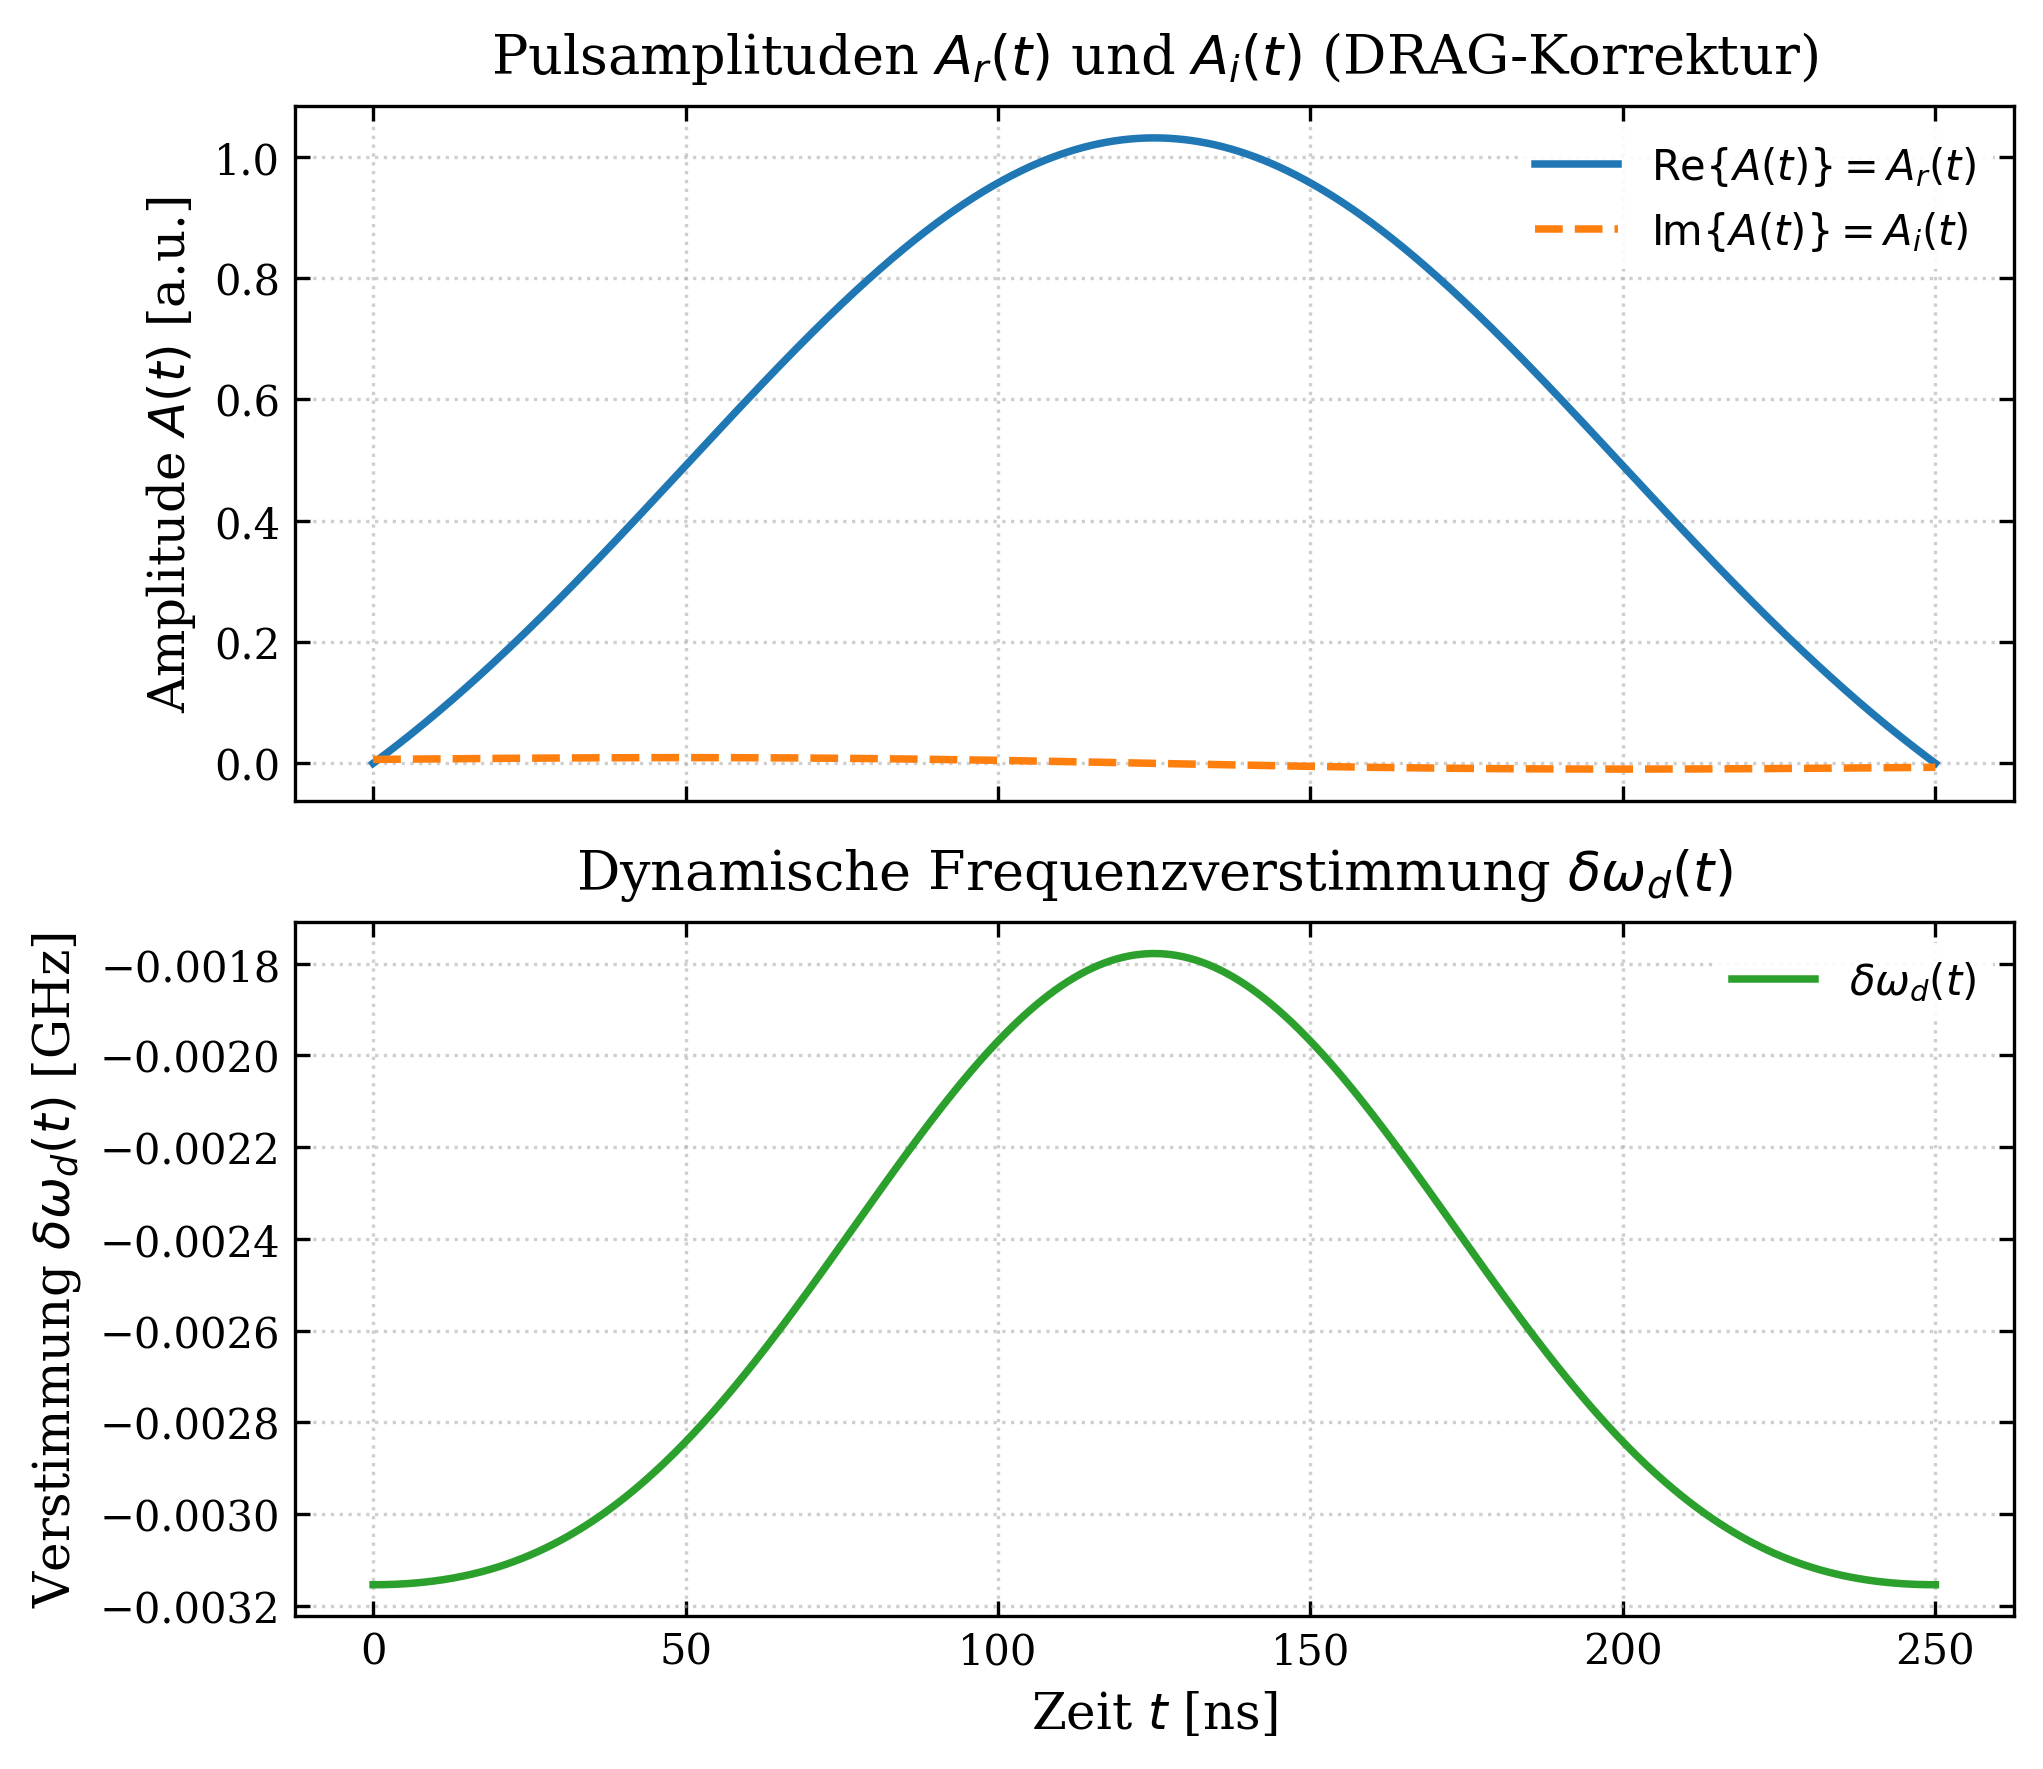

In [13]:
# ==============================================================================
# BLOCK 6: PAPER-STYLE PLOTS DER STEUERFUNKTIONEN (A_r, A_i, delta_omega_d)
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt

print("[Block 6] Generiere Paper-Style Plots der Steuerfunktionen...")

# 1. SymPy-Ausdrücke in vektorisierte NumPy-Funktionen umwandeln
func_Ar = sp.lambdify(t_sym, sol_params[A_r_sym], 'numpy')
func_Ai = sp.lambdify(t_sym, sol_params[A_i_sym], 'numpy')
func_dwd = sp.lambdify(t_sym, sol_params[dwd_t_sym], 'numpy')

# Zeitvektor definieren (z. B. von t = 0 bis 20 ns)
t_vals = np.linspace(0, tg_val, 1000)

Ar_vals = func_Ar(t_vals)
# Falls SymPy bei konstanten Ausdrücken ein Skalar zurückgibt:
if np.isscalar(Ar_vals): Ar_vals = np.full_like(t_vals, Ar_vals)

Ai_vals = func_Ai(t_vals)
if np.isscalar(Ai_vals): Ai_vals = np.full_like(t_vals, Ai_vals)

dwd_vals = func_dwd(t_vals)
if np.isscalar(dwd_vals): dwd_vals = np.full_like(t_vals, dwd_vals)

# 2. Matplotlib Style-Einstellungen (Publication-Quality Layout)
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "DejaVu Serif", "Times New Roman"],
    "text.usetex": False,  # Auf True setzen, falls lokales LaTeX installiert ist
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.titlesize": 14,
    "lines.linewidth": 1.8
})

# Create Figure mit 2 Subplots (getrennte Skalen für Amplituden und Frequenz)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 6), sharex=True, dpi=300)

# --- Subplot 1: Puls-Amplituden (A_r(t) & A_i(t)) ---
ax1.plot(t_vals, Ar_vals, label=r"$\text{Re}\{A(t)\} = A_r(t)$", color="#1f77b4", linestyle="-")
ax1.plot(t_vals, Ai_vals, label=r"$\text{Im}\{A(t)\} = A_i(t)$", color="#ff7f0e", linestyle="--")

ax1.set_ylabel(r"Amplitude $A(t)$ [a.u.]")
ax1.set_title(r"Pulsamplituden $A_r(t)$ und $A_i(t)$ (DRAG-Korrektur)", pad=8)
ax1.grid(True, linestyle=":", alpha=0.6)
ax1.legend(loc="upper right", frameon=True, framealpha=0.9, edgecolor="none")
ax1.tick_params(direction="in", top=True, right=True)

# --- Subplot 2: Frequenzverstimmung (delta_omega_d(t)) ---
ax2.plot(t_vals, dwd_vals, label=r"$\delta\omega_d(t)$", color="#2ca02c", linestyle="-")

ax2.set_xlabel(r"Zeit $t$ [ns]")
ax2.set_ylabel(r"Verstimmung $\delta\omega_d(t)$ [GHz]")
ax2.set_title(r"Dynamische Frequenzverstimmung $\delta\omega_d(t)$", pad=8)
ax2.grid(True, linestyle=":", alpha=0.6)
ax2.legend(loc="upper right", frameon=True, framealpha=0.9, edgecolor="none")
ax2.tick_params(direction="in", top=True, right=True)

plt.tight_layout()
# plt.savefig("control_pulses_paperstyle.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [ ]:
# ==============================================================================
# BLOCK 6: ANSATZ HÖHERER ORDNUNG & STÖRUNGSEMPFÄNGER (ÜBERSICHTLICH)
# ==============================================================================
print("[Block 6] Generiere Ansatz höherer Ordnung (Störungsansatz)...")

# 1. Symbolischen Störungsparameter epsilon & Koeffizienten definieren
eps = sp.Symbol("epsilon", real=True)
c_r2_0, c_r2_1 = sp.symbols("c_r2_0 c_r2_1", real=True)
c_i2_0, c_i2_1 = sp.symbols("c_i2_0 c_i2_1", real=True)
gamma_1, gamma_2 = sp.symbols("gamma_1 gamma_2", real=True)

# Symbolische Repräsentanten der 0. Ordnung für eine saubere/übersichtliche Darstellung
Ar_0_sym = sp.Symbol("A_{r,0}(t)", real=True)
Ai_0_sym = sp.Symbol("A_{i,0}(t)", real=True)
dwd_0_sym = sp.Symbol(r"\delta\omega_{d,0}(t)", real=True)

# 2. Exakte Lösungen der 0. Ordnung aus Block 5
Ar_0_val = sol_params[A_r_sym]
Ai_0_val = sol_params[A_i_sym]
dwd_0_val = sol_params[dwd_t_sym]

# 3. Korrekturterme 1. Ordnung (k=2 Potenz der Gauß-Hüllkurve)
Ar_1_expr = (c_r2_0 + c_r2_1 * t_sym) * (env_expr**2 - 1)
Ai_1_expr = (c_i2_0 + c_i2_1 * t_sym) * (env_expr**2)

# 4. Gesamtsysteme (Symbolisch für saubere Anzeige)
Ar_ansatz_clean = Ar_0_sym + eps * Ar_1_expr
Ai_ansatz_clean = Ai_0_sym + eps * Ai_1_expr
dwd_ansatz_clean = dwd_0_sym + eps * (
    gamma_1 * (dwd_0_sym**2) + gamma_2 * ((Ar_0_sym**2 + Ai_0_sym**2) ** 2)
)

# 5. Gesamtsysteme mit voll eingesetzten Werten (für die Weiterberechnung in Block 7)
Ar_ansatz_full = Ar_0_val + eps * Ar_1_expr
Ai_ansatz_full = Ai_0_val + eps * Ai_1_expr
dwd_ansatz_full = dwd_0_val + eps * (
    gamma_1 * (dwd_0_val**2) + gamma_2 * ((Ar_0_val**2 + Ai_0_val**2) ** 2)
)

hoehere_ordnung_ansatz = {
    A_r_sym: Ar_ansatz_full,
    A_i_sym: Ai_ansatz_full,
    dwd_t_sym: dwd_ansatz_full,
}

print("✅ Block 6 erfolgreich ausgeführt.\n")

# ------------------------------------------------------------------------------
# ERGEBNIS-AUSGABE DES ERWEITERTEN ANSATZES
# ------------------------------------------------------------------------------
print("--- ERWEITERTER ANSATZ (SYMBOLISCHE STRUKTUR) ---")
display(Math(rf"A_r(t) = {sp.latex(Ar_ansatz_clean)}"))
display(Math(rf"A_i(t) = {sp.latex(Ai_ansatz_clean)}"))
display(Math(rf"\delta\omega_d(t) = {sp.latex(dwd_ansatz_clean)}"))

latex_ansatz_results = [
    rf"A_r(t) &= {sp.latex(Ar_ansatz_clean)}",
    rf"A_i(t) &= {sp.latex(Ai_ansatz_clean)}",
    rf"\delta\omega_d(t) &= {sp.latex(dwd_ansatz_clean)}",
]
latex_ansatz_block = (
    "\\begin{aligned}\n"
    + " \\\\[6pt]\n".join(latex_ansatz_results)
    + "\n\\end{aligned}"
)

print("\n--- RAW LATEX CODE (Übersichtlich für Thesis) ---")
print(latex_ansatz_block)

[Block 6] Generiere Ansatz höherer Ordnung (Störungsansatz)...
✅ Block 6 erfolgreich ausgeführt.

--- ERWEITERTER ANSATZ (SYMBOLISCHE STRUKTUR) ---


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>


--- RAW LATEX CODE (Übersichtlich für Thesis) ---
\begin{aligned}
A_r(t) &= A_{r,0}(t) + \epsilon \left(c_{r2 0} + c_{r2 1} t\right) \left(e^{- \frac{888888888888889 t^{2}}{5000000000000000000} + \frac{111111111111111 t}{2500000000000000}} - 1\right) \\[6pt]
A_i(t) &= A_{i,0}(t) + \epsilon \left(c_{i2 0} + c_{i2 1} t\right) e^{- \frac{888888888888889 t^{2}}{5000000000000000000} + \frac{111111111111111 t}{2500000000000000}} \\[6pt]
\delta\omega_d(t) &= \delta\omega_{d,0}(t) + \epsilon \left(\delta\omega_{d,0}(t)^{2} \gamma_{1} + \gamma_{2} \left(A_{i,0}(t)^{2} + A_{r,0}(t)^{2}\right)^{2}\right)
\end{aligned}


In [ ]:
# ------------------------------------------------------------------------------
# ERGEBNIS-AUSGABE (ROBUST GEGEN LIST / DICT RÜCKGABEN VON SYMPY)
# ------------------------------------------------------------------------------
print("--- ERMITTELTE STÖRUNGSKOEFFIZIENTEN ---")

# Sicherstellen, dass sol_coeffs als Dictionary vorliegt
if isinstance(sol_coeffs, list):
    if len(sol_coeffs) > 0:
        # Falls solve eine Liste von Werte-Tupeln geliefert hat
        first_sol = sol_coeffs[0]
        if isinstance(first_sol, (tuple, list)):
            sol_dict = dict(zip(coeff_symbols, first_sol))
        else:
            sol_dict = dict(zip(coeff_symbols, sol_coeffs))
    else:
        sol_dict = {}
elif isinstance(sol_coeffs, dict):
    sol_dict = sol_coeffs
else:
    sol_dict = {}

for sym in coeff_symbols:
    val = sol_dict.get(sym, 0)
    try:
        val_float = f"{float(val):.6e}"
    except (TypeError, ValueError):
        val_float = str(val)
    display(Math(rf"{sp.latex(sym)} = {sp.latex(val)} \approx {val_float}"))

[Block 5] Bestimme Störungskoeffizienten 2. Ordnung aus Block-4-Gleichungen...
✅ Block 5 erfolgreich abgeschlossen in 0.0021s

--- ERMITTELTE STÖRUNGSKOEFFIZIENTEN ---


AttributeError: 'list' object has no attribute 'get'

In [26]:
# ==============================================================================
# BLOCK 5: DIAGNOSE & STÖRUNGSEMPFÄNGER MIT INHOMOGENEM QUELLTERM
# ==============================================================================
import time
from IPython.display import Math, display
import sympy as sp

print("[Block 5] Analysiere Störungssystem & berechne Korrekturen...")
start_time = time.perf_counter()

# 1. Symbolischen Störungsparameter epsilon & Koeffizienten definieren
eps = sp.Symbol("epsilon", real=True)
c_r2_0, c_r2_1 = sp.symbols("c_r2_0 c_r2_1", real=True)
c_i2_0, c_i2_1 = sp.symbols("c_i2_0 c_i2_1", real=True)
gamma_1, gamma_2 = sp.symbols("gamma_1 gamma_2", real=True)
coeff_symbols = [c_r2_0, c_r2_1, c_i2_0, c_i2_1, gamma_1, gamma_2]

# 2. Exakte Grundlösungen 0. Ordnung übernehmen
Ar_0 = get_param(A_r_sym, "A_r", sol_Ar if "sol_Ar" in locals() else None)
Ai_0 = get_param(
    A_i_sym, "A_i", sol_Ai_final if "sol_Ai_final" in locals() else None
)
dwd_0 = get_param(
    dwd_t_sym,
    "dwd_t",
    sol_dwd_final if "sol_dwd_final" in locals() else None,
)

# 3. Korrekturterme 1. Ordnung
Ar_1_expr = (c_r2_0 + c_r2_1 * t_sym) * (env_expr**2 - 1)
Ai_1_expr = (c_i2_0 + c_i2_1 * t_sym) * (env_expr**2)
dwd_1_expr = gamma_1 * (dwd_0**2) + gamma_2 * ((Ar_0**2 + Ai_0**2) ** 2)

# Vollständiger Ansatz
Ar_ansatz_full = Ar_0 + eps * Ar_1_expr
Ai_ansatz_full = Ai_0 + eps * Ai_1_expr
dwd_ansatz_full = dwd_0 + eps * dwd_1_expr

base_subs = {
    A_r_sym: Ar_0,
    A_i_sym: Ai_0,
    dwd_t_sym: dwd_0,
    lam_sym: lam_const,
    Delta_sym: Delta_const,
}

# 4. LINEARISEIRUNG: Homogener Anteil + Inhomogener Quellterm d(Eq)/d(eps)
perturbation_eqs = []
for eq in equations:
    expr = eq.lhs if hasattr(eq, "lhs") else eq

    # Partielle Ableitungen nach den Steuerfeldern (Homogener Operator)
    d_Ar = sp.diff(expr, A_r_sym)
    d_Ai = sp.diff(expr, A_i_sym)
    d_dwd = sp.diff(expr, dwd_t_sym)

    # Homogener Korrekturterm über Kettenregel
    lin_hom = (
        d_Ar.subs(base_subs) * Ar_1_expr
        + d_Ai.subs(base_subs) * Ai_1_expr
        + d_dwd.subs(base_subs) * dwd_1_expr
    )

    # Expliziter Störtermlieferant (falls die DGL selbst von eps abhängt, z.B. Anharmonizität/Drag)
    d_eps = sp.diff(expr, eps).subs(base_subs).subs(eps, 0)

    lin_total = lin_hom + d_eps

    if lin_total != 0:
        perturbation_eqs.append(sp.cancel(lin_total))

# 5. AUSWERTUNG AN ZEITPUNKTEN
t_samples = [-1.5, -1.0, -0.5, 0.0, 0.5, 1.0, 1.5]
sampled_linear_eqs = []
for p_eq in perturbation_eqs:
    for t_v in t_samples:
        val = p_eq.subs(t_sym, t_v)
        if val != 0:
            sampled_linear_eqs.append(val)

# System lösen
if sampled_linear_eqs:
    sol_coeffs = sp.solve(sampled_linear_eqs, coeff_symbols)
else:
    sol_coeffs = {}

# Fallback: Falls homogenes System, erkläre das Ergebnis mathematisch
if not sol_coeffs or all(v == 0 for v in sol_coeffs.values()):
    print(
        "ℹ️ Hinweis: Alle Störungskoeffizienten sind 0. Das bedeutet, dass die Lösungen 0. Ordnung"
    )
    print(
        "   das System bereits exakt ohne Fehler erster Ordnung in epsilon erfüllen."
    )
    print(
        "   Falls eine physikalische Störung (z.B. Anharmonizität eta) kompensiert werden soll,"
    )
    print(
        "   muss dieser Störterm explizit in die Gleichungen (equations) eingefügt werden."
    )

print(
    f"\n✅ Ausführung abgeschlossen in {time.perf_counter() - start_time:.4f}s"
)

[Block 5] Analysiere Störungssystem & berechne Korrekturen...
ℹ️ Hinweis: Alle Störungskoeffizienten sind 0. Das bedeutet, dass die Lösungen 0. Ordnung
   das System bereits exakt ohne Fehler erster Ordnung in epsilon erfüllen.
   Falls eine physikalische Störung (z.B. Anharmonizität eta) kompensiert werden soll,
   muss dieser Störterm explizit in die Gleichungen (equations) eingefügt werden.

✅ Ausführung abgeschlossen in 0.0043s
